# 3.데이터분석_이변량분석(범주vs숫자)

## 3.1.환경준비

### **3.1.1. 라이브러리 불러오기**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as spst

### **3.1.2. 데이터 불러오기**

- 타이타닉 생존자 : 'titanic_train.csv'

|	변수	|	설명	|	값 설명	|
|	----	|	----	|	----	|
|	survived	|	생존여부	|	0 - 사망, 1- 생존	|
|	Pclass	|	Ticket class	|	1 = 1st, 2 = 2nd, 3 = 3rd	|
|	Sex	|	성별	|		|
|	Age	|	Age in years	|		|
|	Sibsp	|	# of siblings / spouses aboard the Titanic	|		|
|	Parch	|	# of parents / children aboard the Titanic	|		|
|	Ticket	|	Ticket number	|		|
|	Fare	|	Passenger fare	|		|
|	Cabin	|	Cabin number	|		|
|	Embarked	|	Port of Embarkation	|	C = Cherbourg, Q = Queenstown, S = Southampton	|


In [56]:
titanic = pd.read_csv('./../00_data/titanic_train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

- 범주별 숫자를 비교할 때 사용되는 방식은 **범주별 평균 비교** 이다.


## 3.2.시각화
- titanic data에서 Age를 Y로 두고 비교해 봅시다.

### 3.2.1. barplot

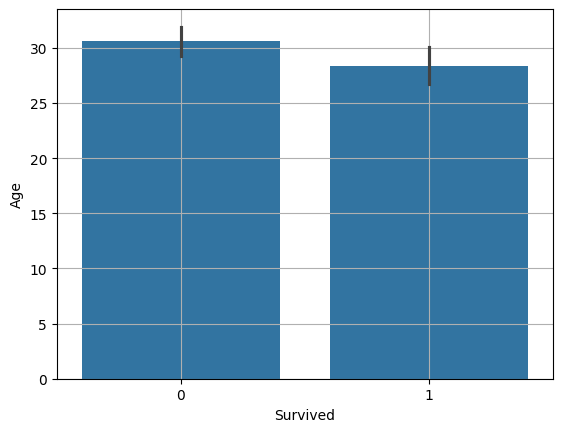

In [57]:
sns.barplot(x='Survived', y='Age', data=titanic)
plt.grid()
plt.show()

In [58]:
# 1. 막대 그래프의 높이
#   - 각 막대는 해당 그룹 (생존자, 사망자)의 평균 나이를 나타냄
# 2. 신뢰 구간 (오차범위)
#   - 막대 위의 세로선은 신뢰구간을 의미, 95% 신뢰구간 : 평균 나이가 이 구간안에 있을 확률이 95%임
# 3. 해석
#   - 생존자는 평균적으로 더 어리지만, 이 차이가 통계적으로 유의미한지는 추가 검정(t-test)이 필요

위 두 범주간에 평균에 차이가 있나요?

- 데이터 분석에서는 두 집단(예: 생존자 vs 사망자) 간에 어떤 차이가 있는지 확인해야 할 때가 많음.
- 예를 들어: 타이타닉호 생존 여부에 따라 평균 나이에 차이가 있을까?
- 대립 가설 : 생존 여부에 따라 나이의 차이가 있다.

### 3.2.2. boxplot

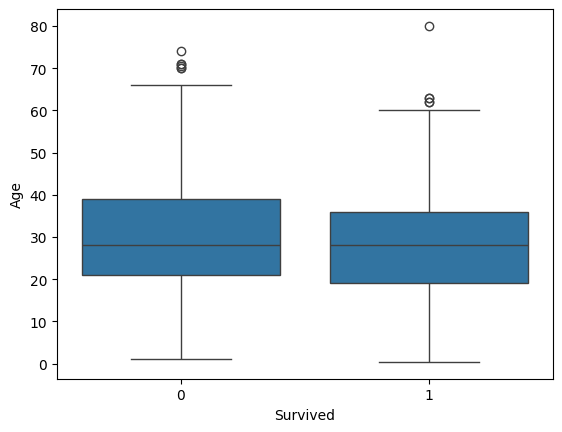

In [59]:
sns. boxplot(x='Survived', y='Age', data=titanic)
plt.show()

## 3.3.수치화

### 3.3.1. t-test

- 두 집단의 평균 비교
    - 예제는 Two sample T-test와 양측검정만 다룬다.
    - 우리는 X --> Y의 관계에서 ,두 변수간에 관련이(차이가) 있는지, 없는지를 확인하는 것이 제일 중요하기 때문이다.

- 주의사항 : 데이터에 NaN이 있으면 계산이 안된다. `.notnull()` 등으로 NaN을 제외한 데이터를 사용해야 한다.

- t 통계량(t-statistic)
    - 두 집단의 평균 차이를 표준오차로 나눈 값
    - 기본적으로는 두 평균의 차이로 이해해도 좋다.
    - 우리의 가설(대립가설)은 차이가 있다는 것이므로, t 값이 크던지 작던지 하기를 바란다.
    - 보통, t 값이 -2보다 작거나, 2보다 크면 차이가 있다고 본다.

* 이번엔 타이타닉 데이터로 시도해 봅시다.
    * 생존여부 --> Age : 생존여부 별로 나이에 차이가 있을것이다.


**1) 데이터 준비**

In [60]:
# 먼저 NaN이 있는지 확인
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [61]:
# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

In [62]:
# 두 그룹으로 데이터 저장
died = temp.loc[temp['Survived']==0, 'Age']
survived = temp.loc[temp['Survived']==1, 'Age']

**2) t-test**

- 귀무가설 : 타이타닉 탑승객 생존 여부별 나이의 차이가 없다.
- 대립가설 : 생존여부에 따른 나이의 차이가 있다.

- 기본 문법 : `ttest_ind(B,A, equal_var=False)`
    - A와 비교할 때 B의 평균이 큰가?
    - equal_var : A와 B의 분산이 같은가?
        - 모르면 False(default)

In [63]:
spst.ttest_ind(died, survived)

# (statistic=np.float64(2.06668694625381), pvalue=np.float64(0.039124654013482474), df=np.float64(712.0))

TtestResult(statistic=np.float64(2.06668694625381), pvalue=np.float64(0.039124654013482474), df=np.float64(712.0))

In [64]:
# t-통계량 : 2.066 -> 2보다 크므로, 차이가 있기는 있으나 크지는 않다.
# p-value: 0.039 -> 0.05보다 작으므로, 귀무가설을 기각하고, 통계적으로 유의미하다.

**<연습문제>**

[문1] 성별에 따라 운임에 차이가 있을 것이다.

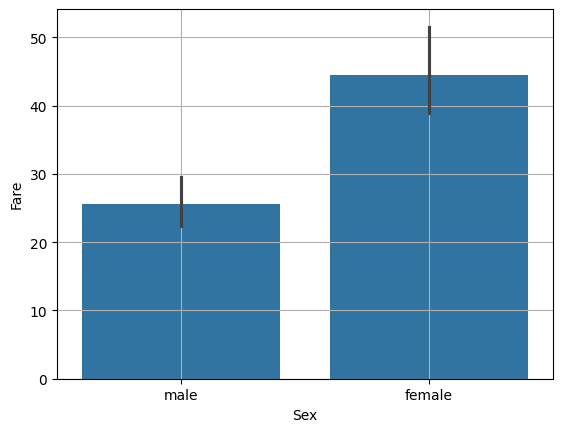

In [65]:
sns.barplot(x=titanic['Sex'], y=titanic['Fare'], data=titanic)
plt.grid()
plt.show()

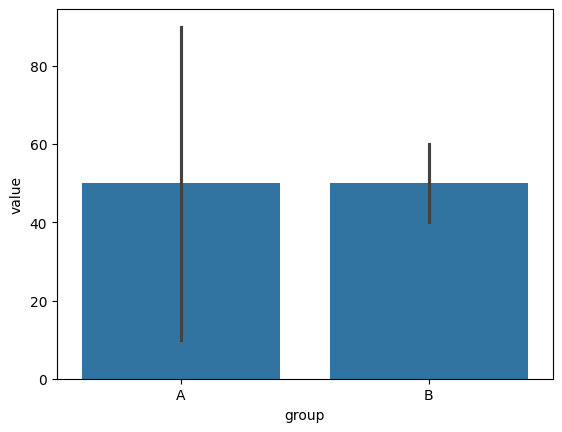

In [66]:
a = [10, 90, 10, 90]   # 평균 50, 분산 큼
b = [40, 60, 60, 40]   # 평균 50, 분산 0

df = pd.DataFrame({
    'value': a + b,
    'group': ['A']*4 + ['B']*4
})

sns.barplot(x='group', y='value', data=df)
# plt.grid()
plt.show()

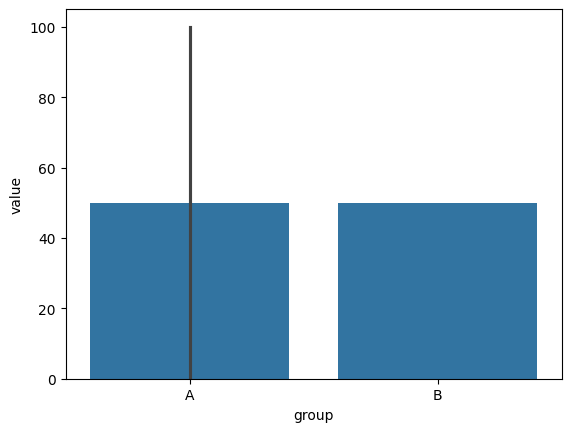

In [67]:
a = [0, 100, 0, 100]   # 평균 50, 분산 큼
b = [50, 50, 50, 50]   # 평균 50, 분산 0

df = pd.DataFrame({
    'value': a + b,
    'group': ['A']*4 + ['B']*4
})

sns.barplot(x='group', y='value', data=df)
# plt.grid()
plt.show()

In [68]:
titanic.info()
titanic.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [69]:
temp = titanic.loc[titanic['Sex'].notnull()]

In [70]:
# female = temp.loc[temp['Sex']=='female','Sex']
# male = temp.loc[temp['Sex']=='male','Sex']

In [71]:
female = temp.loc[temp['Sex']=='female','Fare']
male = temp.loc[temp['Sex']=='male','Fare']
spst.ttest_ind(female, male)

TtestResult(statistic=np.float64(5.529140269385719), pvalue=np.float64(4.230867870043005e-08), df=np.float64(889.0))

In [72]:


male_fare = titanic.loc[titanic['Sex']=='male', 'Fare']
female_fare = titanic.loc[titanic['Sex']=='female', 'Fare']

spst.ttest_ind(male_fare, female_fare)

TtestResult(statistic=np.float64(-5.529140269385719), pvalue=np.float64(4.230867870043005e-08), df=np.float64(889.0))

- 두 집단의 평균 요금 차이는 '우연이 아니라 확실한 차이'
- 여성이 남성보다 요금을 더 많이 냈다.
- 통계적으로 남성과 여성의 평균 요금은 유의미하게 다르다. 

[문2] 생존여부에 따라 운임에 차이가 있을 것이다.

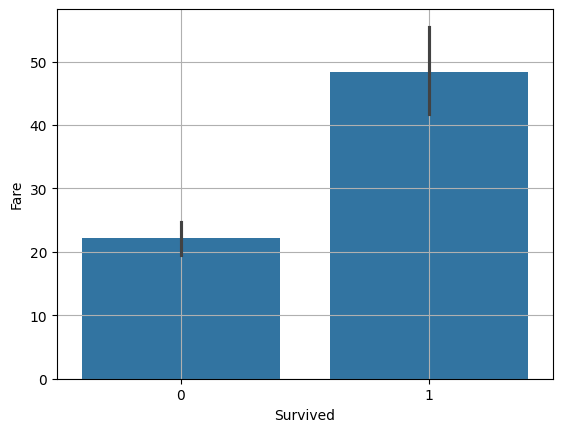

In [73]:
sns.barplot(x=titanic['Survived'], y=titanic['Fare'], data=titanic)
plt.grid()
plt.show()

In [74]:
died = titanic.loc[titanic['Survived']==0,'Fare']
survived = titanic.loc[titanic['Survived']==1,'Fare']

spst.ttest_ind(died, survived)

TtestResult(statistic=np.float64(-7.939191660871055), pvalue=np.float64(6.1201893419242075e-15), df=np.float64(889.0))

In [75]:
# 막대 높이: 생존자의 평균 운임이 사망자의 평균 운임보다 훨씬 높음.
# 오차범위(신뢰구간): 두 그룹의 평균 운임이 통계적으로 유의미하게 다를 가능성이 높음.

### **3.3.2. anova**

- 분산 분석 **AN**alysis **O**f **VA**riance
    - **ANOVA (Analysis of Variance)** 는 셋 이상 집단의 평균 차이가 통계적으로 유의미한지를 검정하는 방법
    - 여러 집단 간에 차이는 어떻게 비교할 수 있을까?
    - 여기서 기준은 **전체 평균** 이다.


$
F \text{ 통계량} = \frac{\text{집단 간 분산}}{\text{집단 내 분산}} =\frac{\text{전체 평균 - 각 집단 평균}}{\text{각 집단의 평균 - 개별 값}}
$

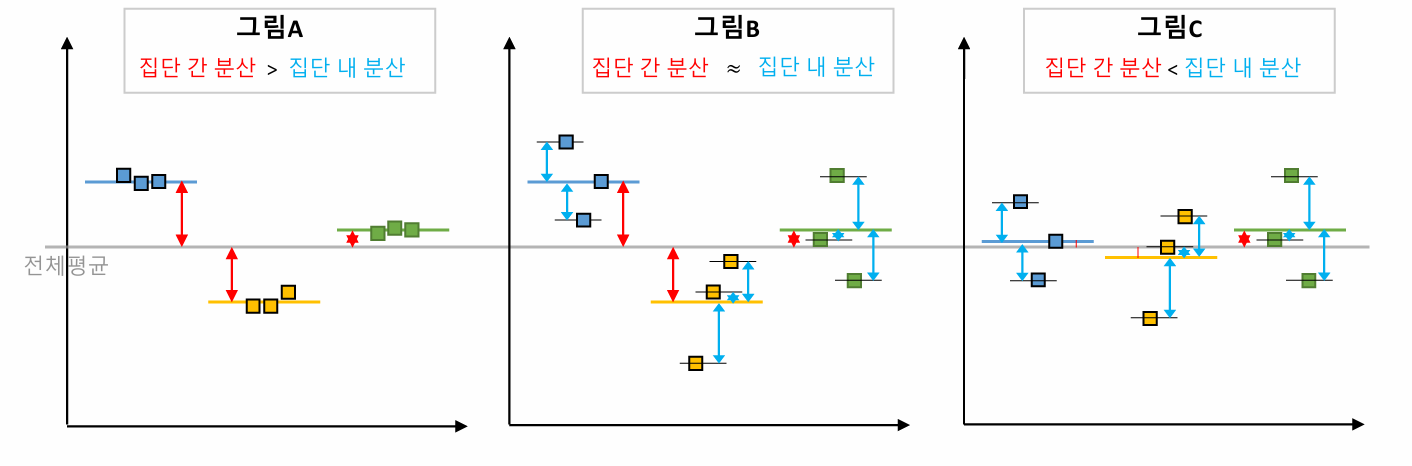

- f분포
    - 두 개의 독립된 정규분포를 따르는 모집단의 분산 비율로 만들어지는 확률 분포
    - 오른쪽으로 길게 늘어진 비대칭 분포를 가지며, 0에서 시작해서 무한대로 이어짐
    - 값이 대략 2~3 이상이면 차이가 있다고 판단한다.

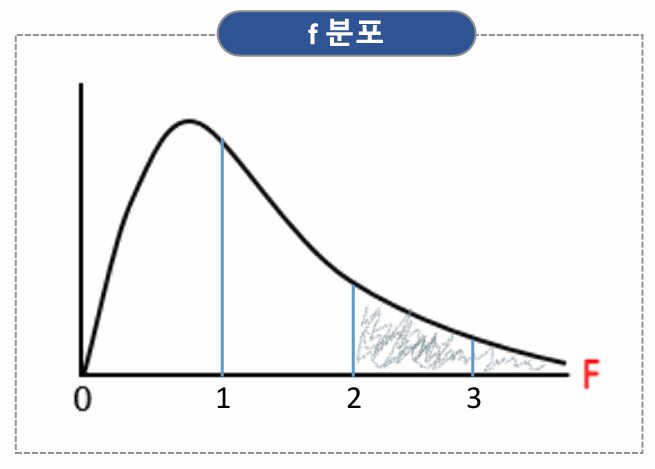

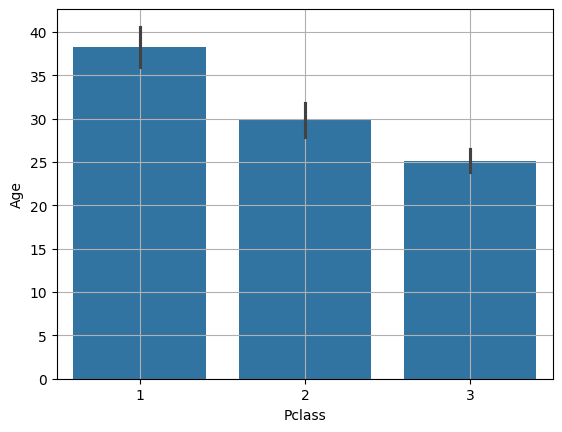

In [76]:
# PClass(3 범주) -> Age
sns.barplot(x='Pclass', y='Age', data=titanic)
plt.grid()
plt.show()

**1) 데이터 준비**

In [77]:
# 분산 분석을 위한 데이터를 만들기

# NaN 행 제외
temp = titanic.loc[titanic['Age'].notnull()]

# 그룹별 저장
# 각 그룹(=집단)의 분포를 따로 분리해서 비교하기 위함

p_1 = temp.loc[temp['Pclass']==1, 'Age']
p_2 = temp.loc[temp['Pclass']==2, 'Age']
p_3 = temp.loc[temp['Pclass']==3, 'Age']


**2) anova**

In [78]:
f_static, p_value = spst.f_oneway(p_1, p_2, p_3)


In [79]:
# Anova 수행
print(f'f_static : {f_static}')
print(f'p_value : {p_value}')

f_static : 57.44348434067624
p_value : 7.487984171957403e-24


In [80]:
# F-통계량: 57.44 -> 세 집단 간의 평균차이가 꽤 큼은 나타냄
# p-value: 0.05 보다 작기 때문에 귀무가설 기각, 통계적으로 유의하다.

**<연습문제>**

[문1] 승선지역(Embarked)별로 운임에 차이가 있을 것이다.
- 시각화와 수치화로 확인해 봅시다.

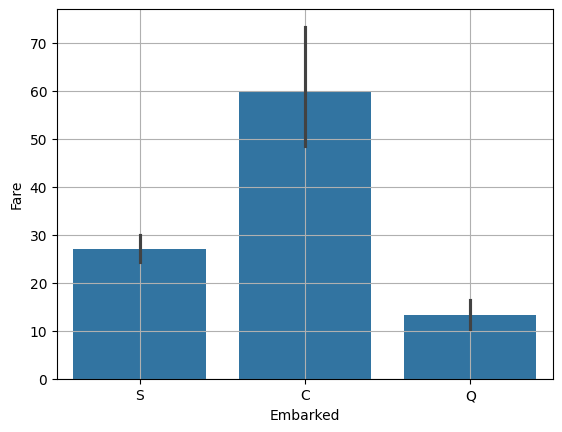

In [81]:
sns.barplot(x='Embarked', y='Fare', data=titanic)
plt.grid()
plt.show()

In [82]:
# 분산 분석을 위한 데이터를 만들기

# NaN 행 제외
temp = titanic.loc[titanic['Fare'].notnull()]

# 그룹별 저장
# 각 그룹(=집단)의 분포를 따로 분리해서 비교하기 위함

p_s = temp.loc[temp['Embarked']=='S', 'Fare']
p_c = temp.loc[temp['Embarked']=='C', 'Fare']
p_q = temp.loc[temp['Embarked']=='Q', 'Fare']

f_static, p_value = spst.f_oneway(p_s, p_c, p_q)

# Anova 수행
print(f'f_static : {f_static}')
print(f'p_value : {p_value}')


f_static : 38.14030520011265
p_value : 1.289645025263729e-16


[문2] 객실등급(Pclass)별로 운임에 차이가 있을 것이다.
- 시각화와 수치화로 확인해 봅시다.

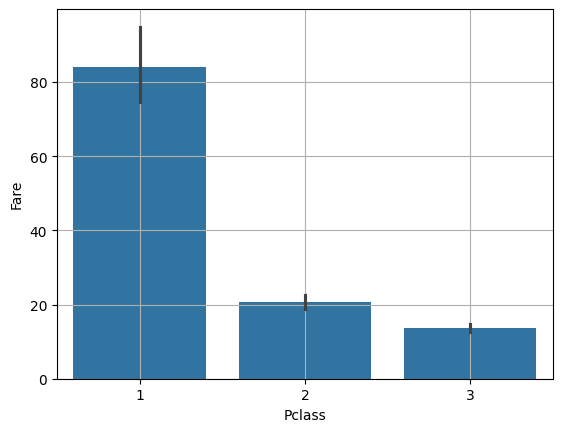

In [83]:
sns.barplot(x='Pclass', y='Fare', data=titanic)
plt.grid()
plt.show()

## 3.4.종합 연습문제

air quality 데이터셋으로 다음 문제를 풀어 봅시다.

* 라이브러리 불러오기

In [84]:
air = pd.read_csv('./../00_data/airquality2.csv')
air.head()

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


* 데이터불러오기

In [85]:
air.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    153 non-null    int64  
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Date     153 non-null    str    
dtypes: float64(2), int64(2), str(1)
memory usage: 6.1 KB


* 1) 주말여부(Weekend) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

In [86]:
air['Week'] = pd.to_datetime(air['Date']).dt.dayofweek

air.head()

# air['Weekend'] = 1

#  air.loc[air['Week'] == 5 | air['Week'] == 6]

,Ozone,Solar.R,Wind,Temp,Date,Week
0,41,190.0,7.4,67,1973-05-01,1
1,36,118.0,8.0,72,1973-05-02,2
2,12,149.0,12.6,74,1973-05-03,3
3,18,313.0,11.5,62,1973-05-04,4
4,19,NaN,14.3,56,1973-05-05,5


In [87]:
air['Weekend'] = 1
air.head()

air.loc[(air['Week'] == 5) | (air['Week'] == 6), 'Weekend'] = 0

In [88]:
air.head(10)

,Ozone,Solar.R,Wind,Temp,Date,Week,Weekend
0,41,190.0,7.4,67,1973-05-01,1,1
1,36,118.0,8.0,72,1973-05-02,2,1
2,12,149.0,12.6,74,1973-05-03,3,1
3,18,313.0,11.5,62,1973-05-04,4,1
4,19,NaN,14.3,56,1973-05-05,5,0
5,28,NaN,14.9,66,1973-05-06,6,0
6,23,299.0,8.6,65,1973-05-07,0,1
7,19,99.0,13.8,59,1973-05-08,1,1
8,8,19.0,20.1,61,1973-05-09,2,1
9,20,194.0,8.6,69,1973-05-10,3,1


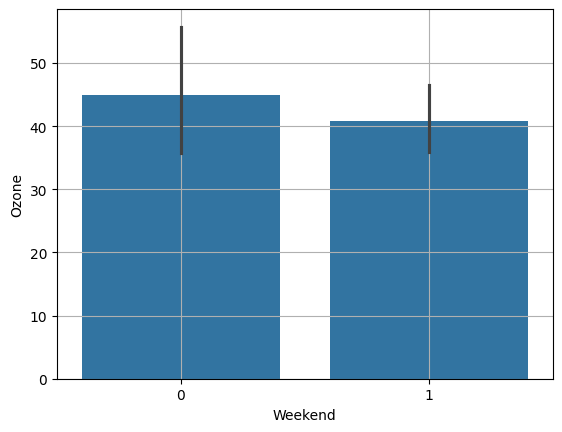

In [90]:
sns.barplot(x='Weekend', y='Ozone', data=air)
plt.grid()
plt.show()

In [91]:

temp = air.loc[air['Weekend'].notnull()]


weekend = temp.loc[temp['Weekend']==1, 'Ozone']
week = temp.loc[temp['Weekend']==0, 'Ozone']


f_static, p_value = spst.f_oneway(weekend, week)

# Anova 수행
print(f'f_static : {f_static}')
print(f'p_value : {p_value}')

f_static : 0.5885175621044181
p_value : 0.4441907648291733


* 2) 요일(Weekday) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

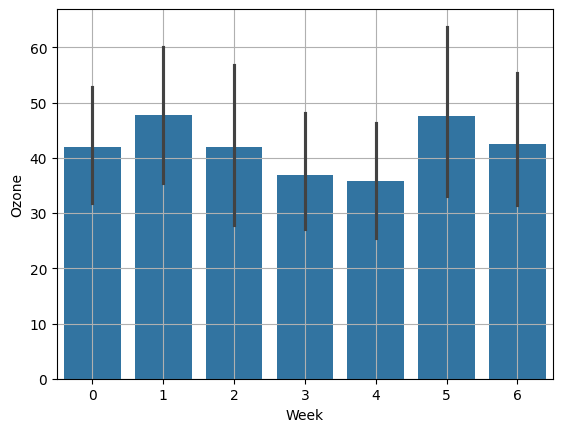

In [92]:
sns.barplot(x='Week', y='Ozone', data=air)
plt.grid()
plt.show()

In [93]:

temp = air.loc[air['Week'].notnull()]


w_0 = temp.loc[temp['Week']==0, 'Ozone']
w_1 = temp.loc[temp['Week']==1, 'Ozone']
w_2 = temp.loc[temp['Week']==2, 'Ozone']
w_3 = temp.loc[temp['Week']==3, 'Ozone']
w_4 = temp.loc[temp['Week']==4, 'Ozone']
w_5 = temp.loc[temp['Week']==5, 'Ozone']
w_6 = temp.loc[temp['Week']==6, 'Ozone']


f_static, p_value = spst.f_oneway(w_0, w_1,w_2,w_3,w_4,w_5, w_6)

# Anova 수행
print(f'f_static : {f_static}')
print(f'p_value : {p_value}')

f_static : 0.5098923426664417
p_value : 0.8001433644111912


* 3) 월(Month) --> 오존농도(Ozone)와의 관계를 시각화하고, 가설검정을 수행해 봅시다.

In [95]:
air['Month'] = pd.to_datetime(air['Date']).dt.month

air.head(10)

,Ozone,Solar.R,Wind,Temp,Date,Week,Weekend,Month
0,41,190.0,7.4,67,1973-05-01,1,1,5
1,36,118.0,8.0,72,1973-05-02,2,1,5
2,12,149.0,12.6,74,1973-05-03,3,1,5
3,18,313.0,11.5,62,1973-05-04,4,1,5
4,19,NaN,14.3,56,1973-05-05,5,0,5
5,28,NaN,14.9,66,1973-05-06,6,0,5
6,23,299.0,8.6,65,1973-05-07,0,1,5
7,19,99.0,13.8,59,1973-05-08,1,1,5
8,8,19.0,20.1,61,1973-05-09,2,1,5
9,20,194.0,8.6,69,1973-05-10,3,1,5


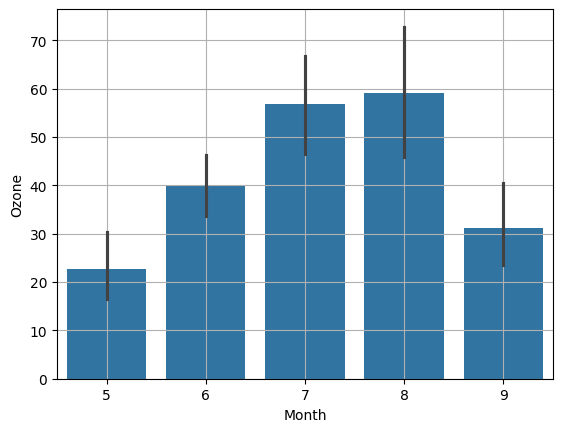

In [96]:
sns.barplot(x='Month', y='Ozone', data=air)
plt.grid()
plt.show()

In [103]:

temp = air.loc[air['Month'].notnull()]


m_5 = temp.loc[temp['Month']==5, 'Ozone']
m_6 = temp.loc[temp['Month']==6, 'Ozone']
m_7 = temp.loc[temp['Month']==7, 'Ozone']
m_8 = temp.loc[temp['Month']==8, 'Ozone']
m_9 = temp.loc[temp['Month']==9, 'Ozone']

m5,m6,m7,m8,m9 = [temp.loc[temp['Month']==mon, 'Ozone'] for mon in range(5,10)]

months_list = [temp.loc[temp['Month']==mon, 'Ozone'] for mon in range(5,10)]


f_static, p_value = spst.f_oneway(m_5, m_6, m_7, m_8, m_9)

f_static_1, p_value_1 = spst.f_oneway(m5, m6, m7, m8, m9)


f_static_2, p_value_2 = spst.f_oneway(*months_list)

# Anova 수행
print(f'f_static : {f_static}')
print(f'p_value : {p_value}')
print()
print(f'f_static : {f_static_1}')
print(f'p_value : {p_value_1}')
print()
print(f'f_static : {f_static_2}')
print(f'p_value : {p_value_2}')

f_static : 10.702965130677125
p_value : 1.202707995452932e-07

f_static : 10.702965130677125
p_value : 1.202707995452932e-07

f_static : 10.702965130677125
p_value : 1.202707995452932e-07
